In [20]:
# set up the python
import cosima_cookbook as cc
from dask.distributed import Client
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import numpy as np
import xarray as xr
import cmocean as cm
import cartopy.crs as ccrs
import cmocean as cm
import cartopy.feature as cft
import cftime
import IPython.display
import sys, os, warnings
import matplotlib.animation as animation
from cartopy.mpl.geoaxes import GeoAxes  # Import GeoAxes for Cartopy plotting
from mpl_toolkits.axes_grid1 import AxesGrid
import gsw
from xhistogram.xarray import histogram as xhistogram
from xgcm import Grid

In [21]:
client = Client(n_workers=28)
client

Perhaps you already have a cluster running?
Hosting the HTTP server on port 43819 instead
  warnings.warn(



Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/43819/status,
Dashboard: /proxy/43819/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42473,Workers: 28
Dashboard: /proxy/43819/status,Total threads: 28
Started: Just now,Total memory: 251.19 GiB
Comm: tcp://127.0.0.1:45877,Total threads: 1
Dashboard: /proxy/39501/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:38841,


In [22]:
session = cc.database.create_session()
db = '/g/data/x77/hm1221/CDW_changes/Jupyter_notebooks/RYF_perturbation.db'
session1 = cc.database.create_session(db)

In [23]:
# time period
start_time1='2152-06-01'
end_time1='2152-08-31'

start_time2='2153-06-01'
end_time2='2153-08-31'

start_time3='2154-06-01'
end_time3='2154-08-31'

In [24]:
# time period
start_time='2152-01-01'
end_time='2154-12-31'

In [25]:
new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')

In [26]:
rho_th_mean_new = xr.open_dataarray('/scratch/x77/hm1221/nc_files/rho_mean_time_th.nc')
rho_ctrl_mean_new = xr.open_dataarray('/scratch/x77/hm1221/nc_files/rho_mean_time_ctrl.nc')
bound_up_mean = xr.open_dataarray('/scratch/x77/hm1221/nc_files/bound_up_mean.nc')
bound_low_mean= xr.open_dataarray("/scratch/x77/hm1221/nc_files/bound_low_mean.nc")

In [27]:
buoyancy_ctrl = cc.querying.getvar(expt='01deg_jra55v13_ryf9091', variable='buoyfreq2_wt', 
                          session=session, frequency='1 monthly').sel(time = slice(start_time, end_time))
buoyancy_th = cc.querying.getvar(expt='01deg_jra55v13_ryf9091_ssp585_th', variable='buoyfreq2_wt', 
                          session=session, frequency='1 monthly').sel(time = slice(start_time, end_time))

/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanager)
/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanager)
/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks

In [28]:
def var_winter(var):
    var_1 = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time1,end_time1)).mean('time').load()
    var_2 = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time2,end_time2)).mean('time').load()
    var_3 = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time3,end_time3)).mean('time').load()

    var_winter = (var_1+var_2+var_3)/3.

    return var_winter

In [29]:
buoyancy_ctrl_winter = var_winter(buoyancy_ctrl)
buoyancy_th_winter = var_winter(buoyancy_th)

In [30]:
st_ocean = new_coord.st_ocean.values

In [31]:
# Interpolate along yu_ocean onto the new yt_ocean coordinate
buoyancy_ctrl_winter = buoyancy_ctrl_winter.interp(sw_ocean=st_ocean)

# Rename the coordinate dimension from 'yu_ocean' to 'yt_ocean'
buoyancy_ctrl_winter = buoyancy_ctrl_winter.rename({'sw_ocean': 'st_ocean'})

In [32]:
# Interpolate along yu_ocean onto the new yt_ocean coordinate
buoyancy_th_winter = buoyancy_th_winter.interp(sw_ocean=st_ocean)

# Rename the coordinate dimension from 'yu_ocean' to 'yt_ocean'
buoyancy_th_winter = buoyancy_th_winter.rename({'sw_ocean': 'st_ocean'})

In [33]:
# transfer the data to latitude to shelf
def Trans_lat_to_shelf(var,new_coord):
    target_bin = np.arange(-20.,60,0.1)
    ds = xr.Dataset({'var': var, 'new_coord': new_coord})
    grid = Grid(ds, coords={'Y': {'center':'yt_ocean'}}, periodic=False)
    # transfer vars 
    var_new = grid.transform(ds['var'], 'Y', target_bin, target_data=ds['new_coord'],method='linear')
    var_new = var_new.rename({'new_coord': 'yt_ocean'})
    var_new_1 = var_new.sel(xt_ocean = slice(-40,80))
    var_new_2 = var_new.sel(xt_ocean = slice(-280,-60))
    var_new = xr.concat([var_new_2,var_new_1],dim = 'xt_ocean')
    var_mean  = var_new.mean('xt_ocean').load()

    return [var_new,var_mean]

In [34]:
buoyancy_ctrl_new,buoyancy_ctrl_mean_new = Trans_lat_to_shelf(buoyancy_ctrl_winter,new_coord)
buoyancy_th_new,buoyancy_th_mean_new = Trans_lat_to_shelf(buoyancy_th_winter,new_coord)


  warnings.warn(

  warnings.warn(



In [35]:
manual_positions = [
    (10, 100), 
    (12, 1000),
    (14,2000)
]
levs_dens = [32.0,32.3,32.5]

In [36]:
# land mask
land = xr.where(np.isnan(buoyancy_ctrl_mean_new[:,:].rename('land')), 1, np.nan)

In [37]:
background_1 = xr.DataArray(
    data=np.ones_like(buoyancy_ctrl_mean_new),
    coords=buoyancy_ctrl_mean_new.coords,
    dims=buoyancy_ctrl_mean_new.dims,
    name='ones_array'
)

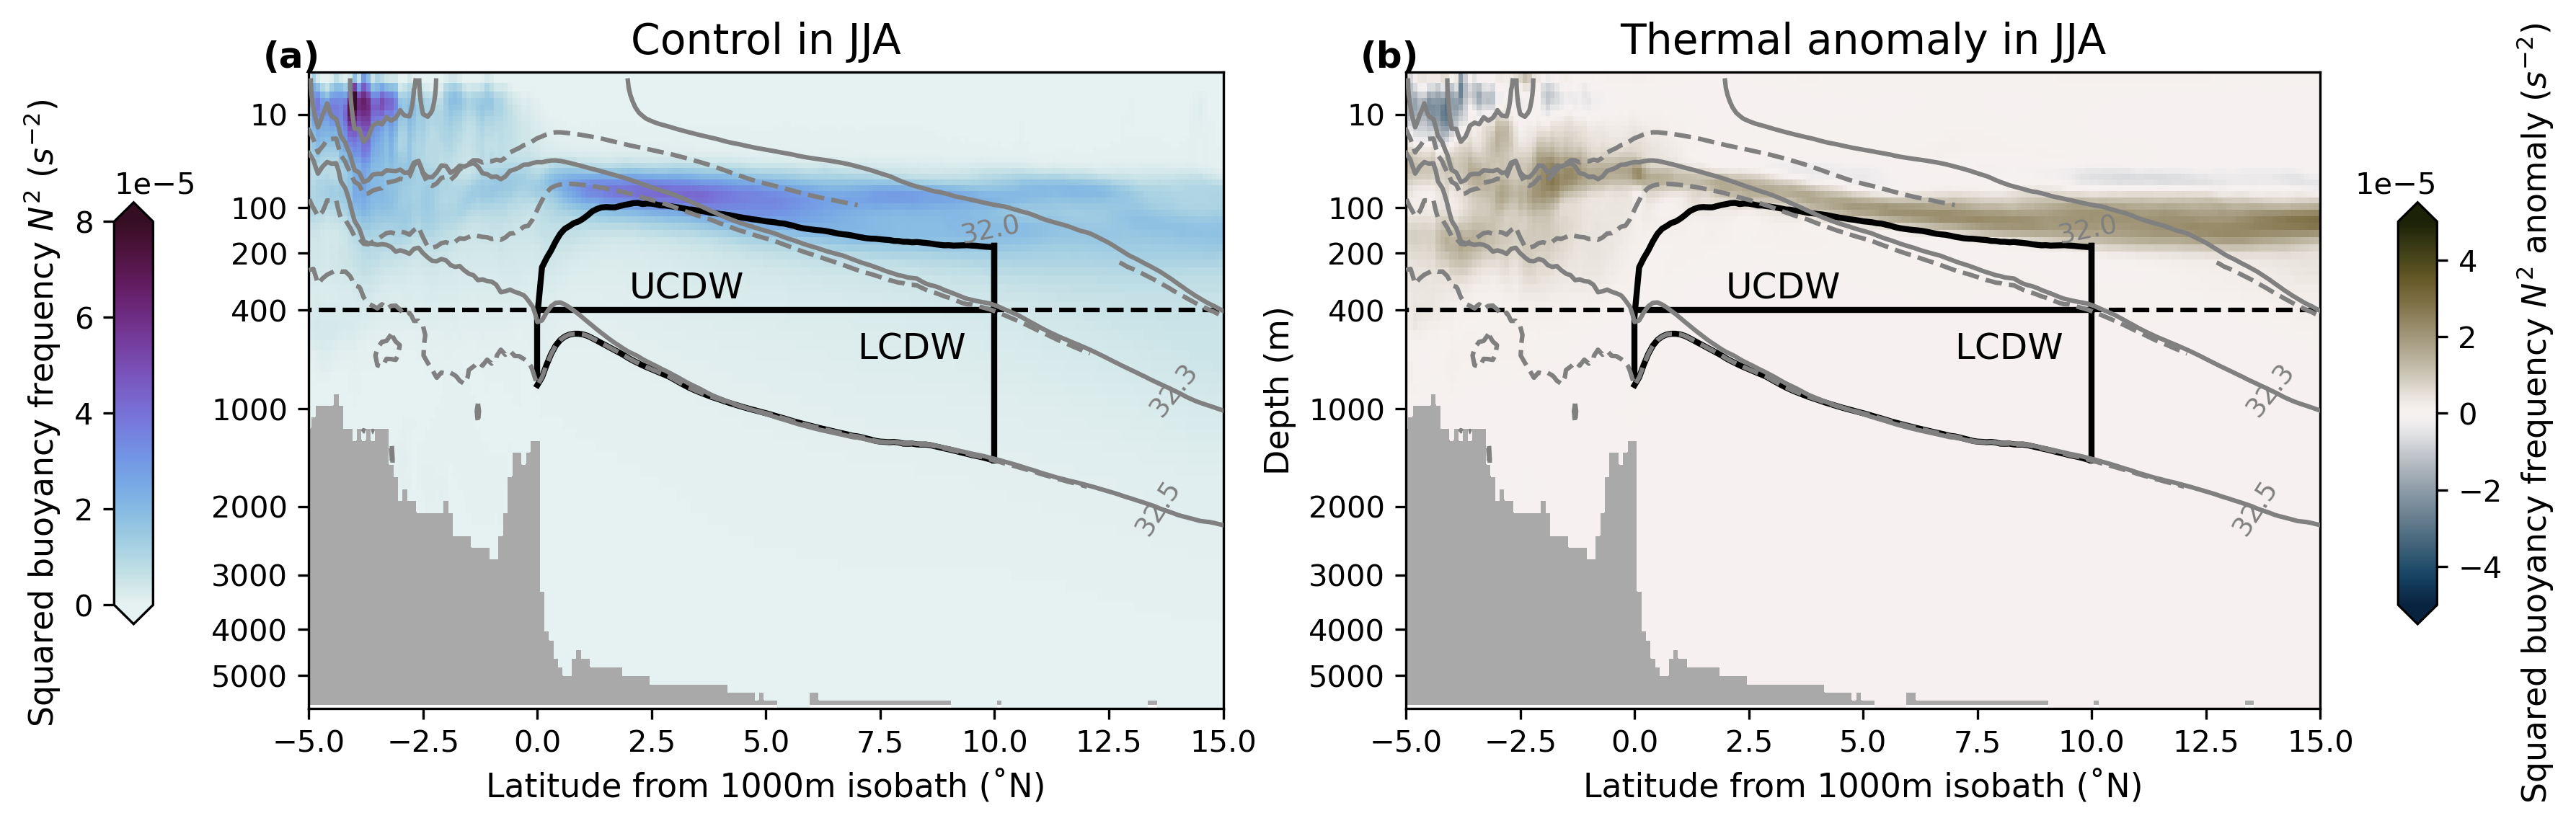

In [39]:
# For Figure 6
fig = plt.figure(figsize=(12,13),dpi = 300)
#ax = plt.subplot(2,1,1)
#plt.plot(rho_bins[1:],(shf_hist_ctrl/1e15).values,color = 'k')
#plt.plot(rho_bins[1:],(shf_hist_th/1e15).values,color = 'r')
#plt.plot([32,32], [-1.5e14/1e15,8e13/1e15], linestyle='--', color='grey')
#plt.plot([32.5,32.5], [-1.5e14/1e15,8e13/1e15], linestyle='--', color='grey')
#plt.xlim(30.5,33)
#plt.ylim(-1.5e14/1e15,8e13/1e15)
#plt.xlabel('$\sigma_1 (kg\ m^{-3})$',fontsize = 11)
#plt.ylabel('surface heat flux (PW)',fontsize = 11)
#plt.title('Surface heat flux in Winter',fontsize = 14)
#plt.legend(['Control','Thermal'], fontsize = 12)
#ax.text(
#        -0.05, 1.05,'(a)', transform=ax.transAxes, fontweight='bold', 
#        fontsize=12,  # Font size
#        verticalalignment='top',  # Align text vertically to the top
#        horizontalalignment='left',  # Align text horizontally to the left
#)

ax = plt.subplot(3,2,5)
background_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p2 = buoyancy_ctrl_mean_new.sel(st_ocean = slice(1.,8000)).plot(vmin=0,vmax=8e-5, cmap = cm.cm.dense,add_colorbar = False)
c2 = plt.contour(bound_up_mean.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_ctrl_mean_new.sel(st_ocean = slice(1.,8000))-1000,levels=levs_dens,colors='grey',linestyles='-',linewidths=1.5,zorder=5)
c2 = plt.contour(bound_up_mean.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_th_mean_new.sel(st_ocean = slice(1.,8000))-1000,levels=levs_dens,colors='grey',linestyles='--',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=9,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions)
land.plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                       add_colorbar=False)
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('Latitude from 1000m isobath (˚N)', fontsize = 11)
plt.ylabel(' ', fontsize = 12)
plt.xlim(-5,15)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
plt.plot([-10,20], [400,400], linestyle='--', color='k')
plt.plot(bound_up_mean[200:300].yt_ocean.values, bound_up_mean[200:300].values, c = 'k',linewidth=2)
plt.plot([10,10],[180,400], c = 'k',linewidth=2)
plt.plot([10,10],[180,400], c = 'k',linewidth=2)
plt.plot([0,10],[400,400], c = 'k',linewidth=2)

plt.plot(bound_up_mean[200:300].yt_ocean.values, bound_low_mean[200:300].values, c = 'k',linewidth=2)
plt.plot([10,10],[400,bound_low_mean[300].values], c = 'k',linewidth=2)
plt.plot([0,0],[400,bound_low_mean[201].values], c = 'k',linewidth=2)
ax.set_title('Control in JJA', fontsize = 14)
ax.text(
        -0.05, 1.05,'(a)', transform=ax.transAxes, fontweight='bold', 
        fontsize=12,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)
plt.text(2,350,'UCDW',fontsize = 12,color = 'k')
plt.text(7,650,'LCDW',fontsize = 12,color = 'k')

ax = plt.subplot(3,2,6)
background_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p1 = (buoyancy_th_mean_new.sel(st_ocean = slice(1.,8000))-buoyancy_ctrl_mean_new.sel(st_ocean = slice(1.,8000))).plot(vmin=-5e-5,vmax=5e-5, cmap = cm.cm.diff,add_colorbar = False)
c2 = plt.contour(bound_up_mean.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_ctrl_mean_new.sel(st_ocean = slice(1.,8000))-1000,levels=levs_dens,colors='grey',linestyles='-',linewidths=1.5,zorder=5)
c2 = plt.contour(bound_up_mean.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_th_mean_new.sel(st_ocean = slice(1.,8000))-1000,levels=levs_dens,colors='grey',linestyles='--',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=9,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions)
land.plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                       add_colorbar=False)
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('Latitude from 1000m isobath (˚N)', fontsize = 11)
plt.ylabel('Depth (m)', fontsize = 11)
plt.xlim(-5,15)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
plt.plot([-10,20], [400,400], linestyle='--', color='k')
plt.plot(bound_up_mean[200:300].yt_ocean.values, bound_up_mean[200:300].values, c = 'k',linewidth=2)
plt.plot([10,10],[180,400], c = 'k',linewidth=2)
plt.plot([10,10],[180,400], c = 'k',linewidth=2)
plt.plot([0,10],[400,400], c = 'k',linewidth=2)

plt.plot(bound_up_mean[200:300].yt_ocean.values, bound_low_mean[200:300].values, c = 'k',linewidth=2)
plt.plot([10,10],[400,bound_low_mean[300].values], c = 'k',linewidth=2)
plt.plot([0,0],[400,bound_low_mean[201].values], c = 'k',linewidth=2)
ax.set_title('Thermal anomaly in JJA', fontsize = 14)
ax.text(
        -0.05, 1.05,'(b)', transform=ax.transAxes, fontweight='bold', 
        fontsize=12,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)
plt.text(2,350,'UCDW',fontsize = 12,color = 'k')
plt.text(7,650,'LCDW',fontsize = 12,color = 'k')

ax_cb2 = plt.axes([0.93, 0.14, 0.015, 0.15])
cb = plt.colorbar(p1, cax=ax_cb2,  orientation='vertical',extend='both')
cb.ax.set_ylabel('Squared buoyancy frequency $N^{2}$ anomaly ($s^{-2}$)', fontsize = 11)

ax_cb2 = plt.axes([0.05, 0.14, 0.015, 0.15])
cb = plt.colorbar(p2, cax=ax_cb2,  orientation='vertical',extend='both')
cb.ax.set_ylabel('Squared buoyancy frequency $N^{2}$ ($s^{-2}$)', fontsize = 11)
cb.ax.yaxis.set_label_position('left')
cb.ax.yaxis.set_ticks_position('left')